# Minh Họa Định Lý Gauss–Markov bằng Monte Carlo

---

## Tổng Quan Các Bước Thực Hiện

| Bước | Nội dung | Mục tiêu |
|------|----------|-----------|
| 1 | Import, thiết lập | Load hàm từ `ols_implementation.py`, đặt seed |
| 2 | Tạo dữ liệu giả lập | Cố định $\mathbf{X}$, $\boldsymbol{\beta}$, $\sigma^2$ |
| 3 | Xây dựng ước lượng thay thế | Tạo $\tilde{\boldsymbol{\beta}}$ — tuyến tính, không chệch, nhưng kém OLS |
| 4 | Vòng lặp Monte Carlo | Lặp $M$ lần, thu thập $\hat{\boldsymbol{\beta}}^{(m)}$ và $\tilde{\boldsymbol{\beta}}^{(m)}$ |
| 5 | Kiểm chứng tính không chệch | So sánh $\bar{\hat{\boldsymbol{\beta}}}$ với $\boldsymbol{\beta}$ thực |
| 6 | Kiểm chứng phương sai | Var thực nghiệm vs. lý thuyết $\sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}$ |
| 7 | Histogram, Q-Q plot | Trực quan hóa phân phối của $\hat{\beta}_j$ |
| 8 | Boxplot OLS và Alt | So sánh sự phân tán của hai ước lượng |
| 9 | Hội tụ theo M | Bias và Var hội tụ khi $M \to \infty$ |
| 10 | Bảng tổng kết và nhận xét | Kết luận toàn bộ thí nghiệm |

**Định lý Gauss–Markov** phát biểu: Dưới GM1–GM4, $\hat{\boldsymbol{\beta}}_{\text{OLS}}$ là **BLUE** (Best Linear Unbiased Estimator):
$$\mathbb{E}[\hat{\boldsymbol{\beta}}_{\text{OLS}}] = \boldsymbol{\beta} \qquad \text{và} \qquad \operatorname{Var}(\hat{\boldsymbol{\beta}}_{\text{OLS}}) = \sigma^2(\mathbf{X}^\top\mathbf{X})^{-1} \preceq \operatorname{Var}(\tilde{\boldsymbol{\beta}})$$
Monte Carlo kiểm chứng điều này bằng cách **lặp lại thí nghiệm $M$ lần** với nhiễu $\boldsymbol{\varepsilon}$ mới mỗi lần.

---
## Bước 1 — Import Thư Viện và Load Hàm từ `ols_implementation.py`

Import `ols_fit` và `hat_matrix` từ file đã cài đặt sẵn.  


In [1]:
%pip install numpy
%pip install matplotlib
%pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from ols_implementation import ols_fit, hat_matrix

# Seed toàn cục
SEED = 42
rng  = np.random.default_rng(SEED)

print(f"  ols_fit    : {ols_fit}")
print(f"  hat_matrix : {hat_matrix}")

  ols_fit    : <function ols_fit at 0x000002865B625940>
  hat_matrix : <function hat_matrix at 0x000002865B625D00>


---
## Bước 2 — Tạo Dữ Liệu Giả Lập (Synthetic Data)

Ta **cố định** $\mathbf{X}$ và $\boldsymbol{\beta}_{\text{true}}$ trong suốt thí nghiệm. Chỉ **nhiễu** $\boldsymbol{\varepsilon}$ thay đổi mỗi lần lặp — đây chính là nguồn ngẫu nhiên duy nhất của Monte Carlo.

Mô hình sinh dữ liệu:
$$\mathbf{y}^{(m)} = \mathbf{X}\boldsymbol{\beta}_{\text{true}} + \boldsymbol{\varepsilon}^{(m)}, \qquad \boldsymbol{\varepsilon}^{(m)} \sim \mathcal{N}(\mathbf{0},\, \sigma^2 \mathbf{I}_n)$$

Các giả thiết Gauss–Markov được thỏa:
- **GM1** (Tuyến tính): $\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$ .
- **GM2** (Hạng đầy đủ): $\operatorname{rank}(\mathbf{X}) = p + 1$.
- **GM3** (Ngoại sinh): $\mathbb{E}[\boldsymbol{\varepsilon} \mid \mathbf{X}] = \mathbf{0}$ (nhiễu có kỳ vọng bằng 0).
- **GM4** (Phương sai không đổi): $\operatorname{Var}(\boldsymbol{\varepsilon} \mid \mathbf{X}) = \sigma^2\mathbf{I}$ (nhiễu i.i.d.)

In [2]:

n         = 60           # số quan sát
p_feat    = 3            # số biến đặc trưng (không kể intercept)
sigma2    = 4.0          # phương sai nhiễu thực sự
sigma     = np.sqrt(sigma2)

# Vector tham số thực: [beta_0, beta_1, beta_2, beta_3]
beta_true = np.array([2.0, -1.5, 3.0, 0.5])  

# ── Xây dựng ma trận design X (cố định) ──────────────────────────────────────
# X_raw ~ N(0,1), sau đó thêm cột 1 (intercept) vào đầu
X_raw = rng.standard_normal((n, p_feat))          
X     = np.column_stack([np.ones(n), X_raw])      

# ── Kiểm tra GM2: rank(X) == p_feat + 1 ──────────────────────────────────────
rank_X = np.linalg.matrix_rank(X)
assert rank_X == p_feat + 1, f"Lỗi: rank(X)={rank_X}"

# ── Phương sai lý thuyết theo công thức Gauss–Markov ─────────────────────────
# Var(beta_hat_j) = sigma^2 * [(X^T X)^{-1}]_{jj}
XtX_inv    = np.linalg.inv(X.T @ X)              # dùng numpy để tính lý thuyết
var_theory = sigma2 * np.diag(XtX_inv)           # shape (p_feat+1,)

print(f"Thiết lập: n={n}, p_feat={p_feat}, sigma^2={sigma2}")
print(f"beta_true = {beta_true}")
print(f"rank(X)   = {rank_X} (GM2 thỏa)")
print()
print("Phương sai lý thuyết  Var(beta_hat_j) = sigma^2 * [(X^TX)^{-1}]_jj:")
for j in range(p_feat + 1):
    print(f"  j={j}: Var(beta_{j}) = {sigma2:.1f} × {XtX_inv[j,j]:.4f} = {var_theory[j]:.4f}")

Thiết lập: n=60, p_feat=3, sigma^2=4.0
beta_true = [ 2.  -1.5  3.   0.5]
rank(X)   = 4 (GM2 thỏa)

Phương sai lý thuyết  Var(beta_hat_j) = sigma^2 * [(X^TX)^{-1}]_jj:
  j=0: Var(beta_0) = 4.0 × 0.0170 = 0.0679
  j=1: Var(beta_1) = 4.0 × 0.0217 = 0.0867
  j=2: Var(beta_2) = 4.0 × 0.0214 = 0.0857
  j=3: Var(beta_3) = 4.0 × 0.0292 = 0.1168


---
## Bước 3 — Xây Dựng Ước Lượng Tuyến Tính Không Chệch Thay Thế

Để minh họa tính **Best** của OLS, ta cần một ước lượng $\tilde{\boldsymbol{\beta}}$ thỏa:
- **Tuyến tính:** $\tilde{\boldsymbol{\beta}} = \mathbf{C}\mathbf{y}$
- **Không chệch:** $\mathbb{E}[\tilde{\boldsymbol{\beta}}] = \boldsymbol{\beta}$ — yêu cầu $\mathbf{C}\mathbf{X} = \mathbf{I}$
- **Không phải OLS:** $\mathbf{C} \neq (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top$

**Cách xây dựng:** Viết $\mathbf{C} = \mathbf{A} + \mathbf{D}$ với $\mathbf{A} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top$ (OLS).  
Điều kiện không chệch: $(\mathbf{A}+\mathbf{D})\mathbf{X} = \mathbf{I}$ $\Rightarrow$ $\mathbf{D}\mathbf{X} = \mathbf{0}$.  
Chọn $\mathbf{D} = \mathbf{E}(\mathbf{I}-\mathbf{H})$ với $\mathbf{E}$ tùy ý, vì $(\mathbf{I}-\mathbf{H})\mathbf{X} = \mathbf{0}$ luôn đúng.

In [3]:
def alternative_estimator(X, y, H, scale=0.4):
    """
    Ước lượng tuyến tính không chệch thay thế OLS.
    """
    n, k = X.shape
    A = np.linalg.inv(X.T @ X) @ X.T          
    I_minus_H = np.eye(n) - H                 

    # E cố định để D không đổi qua các lần lặp
    rng_E = np.random.default_rng(SEED)
    E     = scale * rng_E.standard_normal((k, n))  # (k, n)
    D     = E @ I_minus_H                      # (k, n), thỏa D X = 0

    # Kiểm tra điều kiện không chệch: D X ≈ 0
    assert np.allclose(D @ X, 0, atol=1e-10), "DX ≠ 0: ước lượng bị chệch!"

    C        = A + D                           # (k, n)
    beta_alt = C @ y                           # (k,)
    return beta_alt


H = hat_matrix(X)    

# Tạo nhiễu ngẫu nhiên và tính thử
eps_demo = rng.normal(0, sigma, n)
y_demo   = X @ beta_true + eps_demo

beta_ols_demo, sigma2_demo = ols_fit(X, y_demo)
beta_ols_demo = beta_ols_demo.flatten()

beta_alt_demo = alternative_estimator(X, y_demo, H, scale=0.4)

print("Kiểm tra nhanh trên 1 mẫu:")
print(f"  beta_true    : {beta_true}")
print(f"  beta_hat_OLS : {beta_ols_demo.round(4)}")
print(f"  beta_hat_Alt : {beta_alt_demo.round(4)}")
print(f"  sigma2_hat   : {sigma2_demo:.4f}  (true={sigma2})")

Kiểm tra nhanh trên 1 mẫu:
  beta_true    : [ 2.  -1.5  3.   0.5]
  beta_hat_OLS : [ 1.9907 -0.7943  3.0547  0.6789]
  beta_hat_Alt : [ 3.8407 -9.0911  7.9713 43.1897]
  sigma2_hat   : 3.7956  (true=4.0)


---
## Bước 4 — Vòng Lặp Monte Carlo

**Thuật toán:**  
Lặp $m = 1, \ldots, M$:
1. Sinh $\boldsymbol{\varepsilon}^{(m)} \sim \mathcal{N}(\mathbf{0}, \sigma^2\mathbf{I})$
2. Tính $\mathbf{y}^{(m)} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}^{(m)}$
3. Tính $\hat{\boldsymbol{\beta}}^{(m)} = $ `ols_fit(X, y)` $\to$ lưu vào `betas_ols[m]`
4. Tính $\tilde{\boldsymbol{\beta}}^{(m)} = $ `alternative_estimator(...)` $\to$ lưu vào `betas_alt[m]`

$\mathbf{X}$ và $\boldsymbol{\beta}$ **không thay đổi** qua các lần lặp.

In [4]:
M = 2000    # số lần lặp Monte Carlo 

# Khởi tạo mảng lưu kết quả
betas_ols = np.zeros((M, p_feat + 1))   
betas_alt = np.zeros((M, p_feat + 1)) 

for m in range(M):
    # Bước 1: Sinh nhiễu ngẫu nhiên mới mỗi lần lặp
    eps_m = rng.normal(0, sigma, n)     

    # Bước 2: Sinh vector quan sát
    y_m = X @ beta_true + eps_m         

    # Bước 3: Ước lượng OLS — dùng hàm từ ols_implementation.py
    beta_m, _ = ols_fit(X, y_m)
    betas_ols[m] = beta_m.flatten()

    # Bước 4: Ước lượng thay thế
    betas_alt[m] = alternative_estimator(X, y_m, H, scale=0.4)

print(f"  betas_ols : shape {betas_ols.shape}")
print(f"  betas_alt : shape {betas_alt.shape}")

  betas_ols : shape (2000, 4)
  betas_alt : shape (2000, 4)


---
## Bước 5 — Kiểm Chứng Tính Không Chệch

Luật Số Lớn đảm bảo:
$$\bar{\hat{\boldsymbol{\beta}}} = \frac{1}{M}\sum_{m=1}^{M}\hat{\boldsymbol{\beta}}^{(m)} \xrightarrow{M\to\infty} \mathbb{E}[\hat{\boldsymbol{\beta}}_{\text{OLS}}]$$

Nếu OLS không chệch, ta kỳ vọng $\bar{\hat{\boldsymbol{\beta}}} \approx \boldsymbol{\beta}_{\text{true}}$ (bias $\approx 0$).  
Cả ước lượng thay thế cũng phải không chệch do cách xây dựng $\mathbf{D}\mathbf{X} = \mathbf{0}$.

In [5]:
# Trung bình qua M lần lặp ≈ E[beta_hat]
mean_ols = betas_ols.mean(axis=0)    
mean_alt = betas_alt.mean(axis=0)    

bias_ols = mean_ols - beta_true      
bias_alt = mean_alt - beta_true

print("═" * 68)
print(f"  Kiểm Chứng Tính Không Chệch  (M = {M} lần lặp)")
print("═" * 68)
print(f"{'j':>4} {'beta_true':>11} {'E[OLS]':>10} {'Bias_OLS':>12} {'E[Alt]':>10} {'Bias_Alt':>12}")
print("─" * 68)
for j in range(p_feat + 1):
    print(f"  {j:>2}  {beta_true[j]:>11.5f} {mean_ols[j]:>10.5f} "
          f"{bias_ols[j]:>12.7f} {mean_alt[j]:>10.5f} {bias_alt[j]:>12.7f}")
print("─" * 68)
print(f"  max|Bias_OLS| = {np.abs(bias_ols).max():.7f}")
print(f"  max|Bias_Alt| = {np.abs(bias_alt).max():.7f}")
print()
print("→ Cả hai ước lượng đều không chệch (bias ≈ 0)")
print("→ Sự khác biệt ở phương sai")

════════════════════════════════════════════════════════════════════
  Kiểm Chứng Tính Không Chệch  (M = 2000 lần lặp)
════════════════════════════════════════════════════════════════════
   j   beta_true     E[OLS]     Bias_OLS     E[Alt]     Bias_Alt
────────────────────────────────────────────────────────────────────
   0      2.00000    1.99326   -0.0067413    1.93314   -0.0668557
   1     -1.50000   -1.49947    0.0005281   -1.45970    0.0403041
   2      3.00000    3.00576    0.0057606    2.81301   -0.1869863
   3      0.50000    0.50002    0.0000161    0.59162    0.0916233
────────────────────────────────────────────────────────────────────
  max|Bias_OLS| = 0.0067413
  max|Bias_Alt| = 0.1869863

→ Cả hai ước lượng đều không chệch (bias ≈ 0)
→ Sự khác biệt ở phương sai


---
## Bước 6 — Kiểm Chứng Phương Sai: Thực Nghiệm vs. Lý Thuyết

Công thức lý thuyết (Định lý Gauss–Markov):
$$\operatorname{Var}(\hat{\beta}_j^{\text{OLS}}) = \sigma^2 \left[(\mathbf{X}^\top\mathbf{X})^{-1}\right]_{jj}$$

Phương sai thực nghiệm từ Monte Carlo:
$$\widehat{\operatorname{Var}}(\hat{\beta}_j) = \frac{1}{M-1}\sum_{m=1}^{M}\left(\hat{\beta}_j^{(m)} - \bar{\hat{\beta}}_j\right)^2$$

Ta kỳ vọng: phương sai OLS thực nghiệm ≈ lý thuyết, và **Var(Alt) > Var(OLS)**.

In [6]:
# Phương sai thực nghiệm (ddof=1 để ước lượng không chệch)
var_ols_emp = betas_ols.var(axis=0, ddof=1)   
var_alt_emp = betas_alt.var(axis=0, ddof=1)   

print("═" * 72)
print("  So Sánh Phương Sai")
print("═" * 72)
print(f"{'j':>4} {'Var_theory':>12} {'Var_OLS_emp':>13} {'Sai số %':>10} "
      f"{'Var_Alt_emp':>13} {'Alt/OLS':>9}")
print("─" * 72)
for j in range(p_feat + 1):
    err_pct = abs(var_ols_emp[j] - var_theory[j]) / var_theory[j] * 100
    ratio   = var_alt_emp[j] / var_ols_emp[j]
    print(f"  {j:>2}  {var_theory[j]:>12.5f} {var_ols_emp[j]:>13.5f} "
          f"{err_pct:>9.2f}% {var_alt_emp[j]:>13.5f} {ratio:>9.3f}×")
print("─" * 72)
print()
print("Var_OLS_emp ≈ Var_theory → Công thức sigma^2*(X^TX)^{-1} được xác nhận.")
print("Var_Alt_emp > Var_OLS_emp (tỉ lệ > 1×) với mọi j → OLS là BEST (BLUE).")

════════════════════════════════════════════════════════════════════════
  So Sánh Phương Sai
════════════════════════════════════════════════════════════════════════
   j   Var_theory   Var_OLS_emp   Sai số %   Var_Alt_emp   Alt/OLS
────────────────────────────────────────────────────────────────────────
   0       0.06793       0.07080      4.22%      23.10970   326.429×
   1       0.08674       0.09090      4.79%      22.40942   246.541×
   2       0.08574       0.08582      0.10%      37.33382   435.001×
   3       0.11680       0.11968      2.47%      34.88095   291.440×
────────────────────────────────────────────────────────────────────────

Var_OLS_emp ≈ Var_theory → Công thức sigma^2*(X^TX)^{-1} được xác nhận.
Var_Alt_emp > Var_OLS_emp (tỉ lệ > 1×) với mọi j → OLS là BEST (BLUE).


---
## Bước 7 — Histogram & Q-Q Plot: Phân Phối của $\hat{\beta}_j$

Dưới GM5, lý thuyết cho:
$$\hat{\beta}_j^{\text{OLS}} \sim \mathcal{N}\!\left(\beta_j,\; \sigma^2[(\mathbf{X}^\top\mathbf{X})^{-1}]_{jj}\right)$$

- **Histogram** so sánh phân phối thực nghiệm của OLS và Alt với đường cong chuẩn lý thuyết.
- **Q-Q plot** kiểm tra tính chuẩn: các điểm nằm gần đường $y=x$ → phân phối chuẩn.

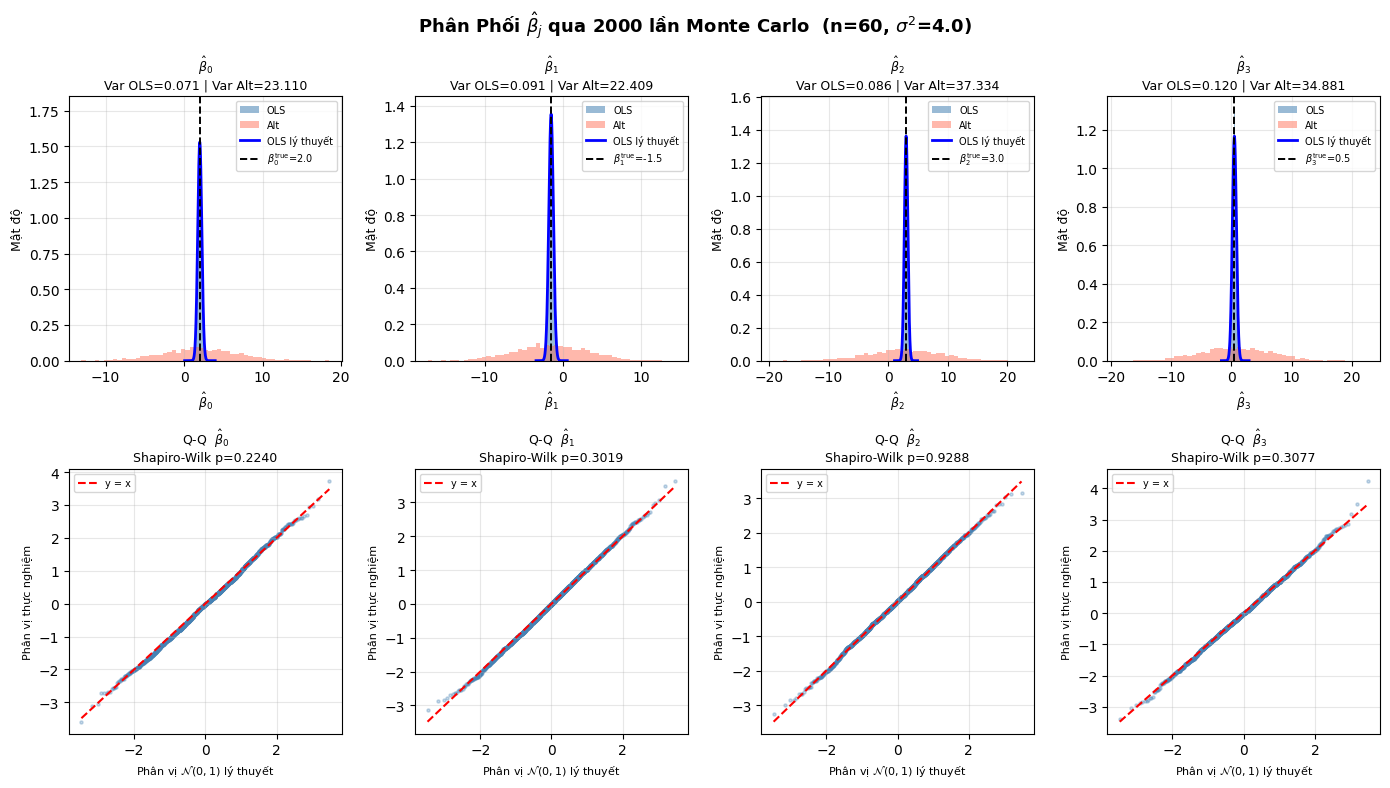

→ Histogram OLS khớp đường cong lý thuyết N(beta_j, Var_theory)
→ Q-Q plot: điểm gần đường y=x, Shapiro p>0.05 → phân phối chuẩn 
→ Histogram Alt rộng hơn OLS → Var(Alt) > Var(OLS)


In [7]:
fig, axes = plt.subplots(2, p_feat + 1, figsize=(14, 8))
fig.suptitle(
    f"Phân Phối $\\hat{{\\beta}}_j$ qua {M} lần Monte Carlo  "
    f"(n={n}, $\\sigma^2$={sigma2})",
    fontsize=13, fontweight='bold'
)

for j in range(p_feat + 1):
    data_ols = betas_ols[:, j]
    data_alt = betas_alt[:, j]

    # Hàng trên: Histogram
    ax_hist = axes[0, j]

    ax_hist.hist(data_ols, bins=55, density=True, alpha=0.55,
                 color='steelblue', label='OLS')
    ax_hist.hist(data_alt, bins=55, density=True, alpha=0.45,
                 color='tomato', label='Alt')

    # Đường cong chuẩn lý thuyết của OLS
    mu_th  = beta_true[j]
    std_th = np.sqrt(var_theory[j])
    xr     = np.linspace(data_ols.min() - 1, data_ols.max() + 1, 300)
    ax_hist.plot(xr, stats.norm.pdf(xr, mu_th, std_th),
                 'b-', linewidth=2, label='OLS lý thuyết')
    ax_hist.axvline(beta_true[j], color='black', linestyle='--',
                    linewidth=1.4, label=f'$\\beta_{j}^{{\\rm true}}$={beta_true[j]}')

    ax_hist.set_title(
        f"$\\hat{{\\beta}}_{j}$\n"
        f"Var OLS={var_ols_emp[j]:.3f} | Var Alt={var_alt_emp[j]:.3f}",
        fontsize=9
    )
    ax_hist.set_xlabel(f"$\\hat{{\\beta}}_{j}$", fontsize=9)
    ax_hist.set_ylabel('Mật độ', fontsize=9)
    ax_hist.legend(fontsize=7)
    ax_hist.grid(alpha=0.3)

    # Hàng dưới: Q-Q Plot 
    ax_qq = axes[1, j]

    # Chuẩn hóa về N(0,1) theo phân phối lý thuyết
    z_scores = (data_ols - mu_th) / std_th
    probs    = (np.arange(1, M + 1) - 0.5) / M
    q_emp    = np.sort(z_scores)
    q_theo   = stats.norm.ppf(probs)

    ax_qq.scatter(q_theo, q_emp, alpha=0.3, s=5, color='steelblue')
    lim = max(abs(q_theo[[0, -1]]))
    ax_qq.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5, label='y = x')

    # Shapiro-Wilk trên 1000 mẫu đầu (tối đa 5000)
    _, sw_p = stats.shapiro(data_ols[:1000])
    ax_qq.set_title(
        f"Q-Q  $\\hat{{\\beta}}_{j}$\nShapiro-Wilk p={sw_p:.4f}",
        fontsize=9
    )
    ax_qq.set_xlabel('Phân vị $\\mathcal{N}(0,1)$ lý thuyết', fontsize=8)
    ax_qq.set_ylabel('Phân vị thực nghiệm', fontsize=8)
    ax_qq.legend(fontsize=7)
    ax_qq.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("→ Histogram OLS khớp đường cong lý thuyết N(beta_j, Var_theory)")
print("→ Q-Q plot: điểm gần đường y=x, Shapiro p>0.05 → phân phối chuẩn ")
print("→ Histogram Alt rộng hơn OLS → Var(Alt) > Var(OLS)")

---
## Bước 8 — Boxplot: So Sánh Phân Tán OLS vs. Ước Lượng Thay Thế

Boxplot trực quan hóa:
- **Vị trí trung tâm** (median): cả hai đều ≈ $\beta_{j}^{\text{true}}$ → không chệch.
- **Độ rộng hộp (IQR):** Alt rộng hơn OLS → phương sai lớn hơn → OLS **tốt hơn**.

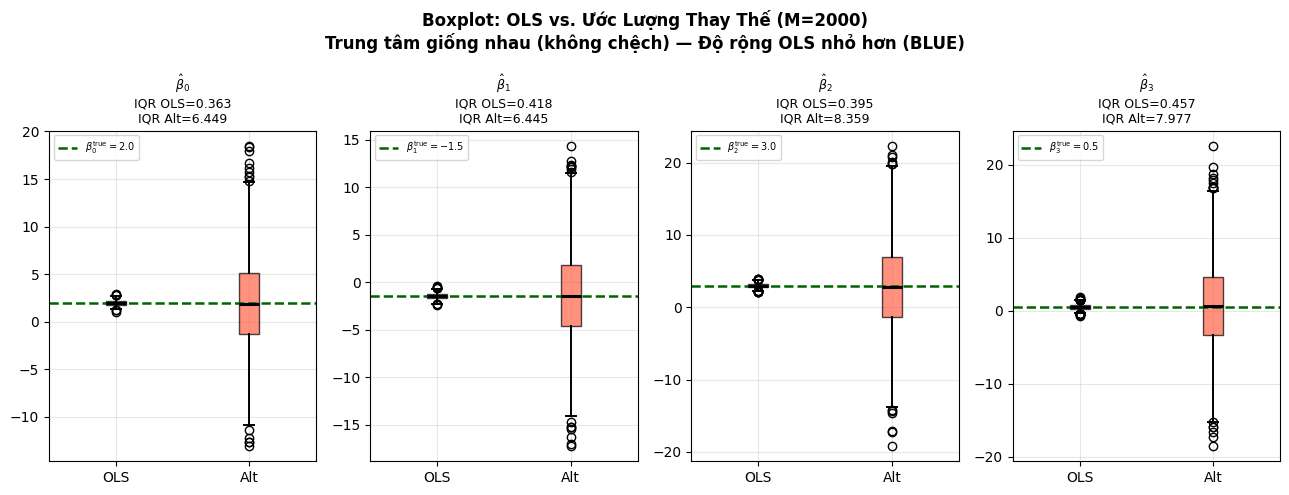

→ Median cả hai ≈ beta_true -> cả hai không chệch
→ IQR(OLS) < IQR(Alt): OLS tập trung hơn quanh giá trị thực


In [8]:
fig, axes = plt.subplots(1, p_feat + 1, figsize=(13, 5), sharey=False)
fig.suptitle(
    f'Boxplot: OLS vs. Ước Lượng Thay Thế (M={M})\n'
    'Trung tâm giống nhau (không chệch) — Độ rộng OLS nhỏ hơn (BLUE)',
    fontsize=12, fontweight='bold'
)

for j, ax in enumerate(axes):
    bp = ax.boxplot(
        [betas_ols[:, j], betas_alt[:, j]],
        tick_labels=['OLS', 'Alt'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2.2),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.4)
    )
    bp['boxes'][0].set(facecolor='steelblue', alpha=0.7)
    bp['boxes'][1].set(facecolor='tomato',    alpha=0.7)

    # Đường ngang tại beta_true
    ax.axhline(beta_true[j], color='darkgreen', linestyle='--',
               linewidth=1.8, label=f'$\\beta_{j}^{{\\rm true}}={beta_true[j]}$')

    iqr_ols = (np.percentile(betas_ols[:, j], 75)
               - np.percentile(betas_ols[:, j], 25))
    iqr_alt = (np.percentile(betas_alt[:, j], 75)
               - np.percentile(betas_alt[:, j], 25))

    ax.set_title(
        f'$\\hat{{\\beta}}_{j}$\n'
        f'IQR OLS={iqr_ols:.3f}\nIQR Alt={iqr_alt:.3f}',
        fontsize=9
    )
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("→ Median cả hai ≈ beta_true -> cả hai không chệch")
print("→ IQR(OLS) < IQR(Alt): OLS tập trung hơn quanh giá trị thực")

---
## Bước 9 — Hội Tụ theo M: Bias và Phương Sai

Hai biểu đồ hội tụ chứng minh tính nhất quán của Monte Carlo:
1. **Bias tích lũy** → 0 khi $M$ tăng (Luật Số Lớn)
2. **Phương sai tích lũy OLS** → hằng số lý thuyết $\sigma^2[(\mathbf{X}^\top\mathbf{X})^{-1}]_{jj}$

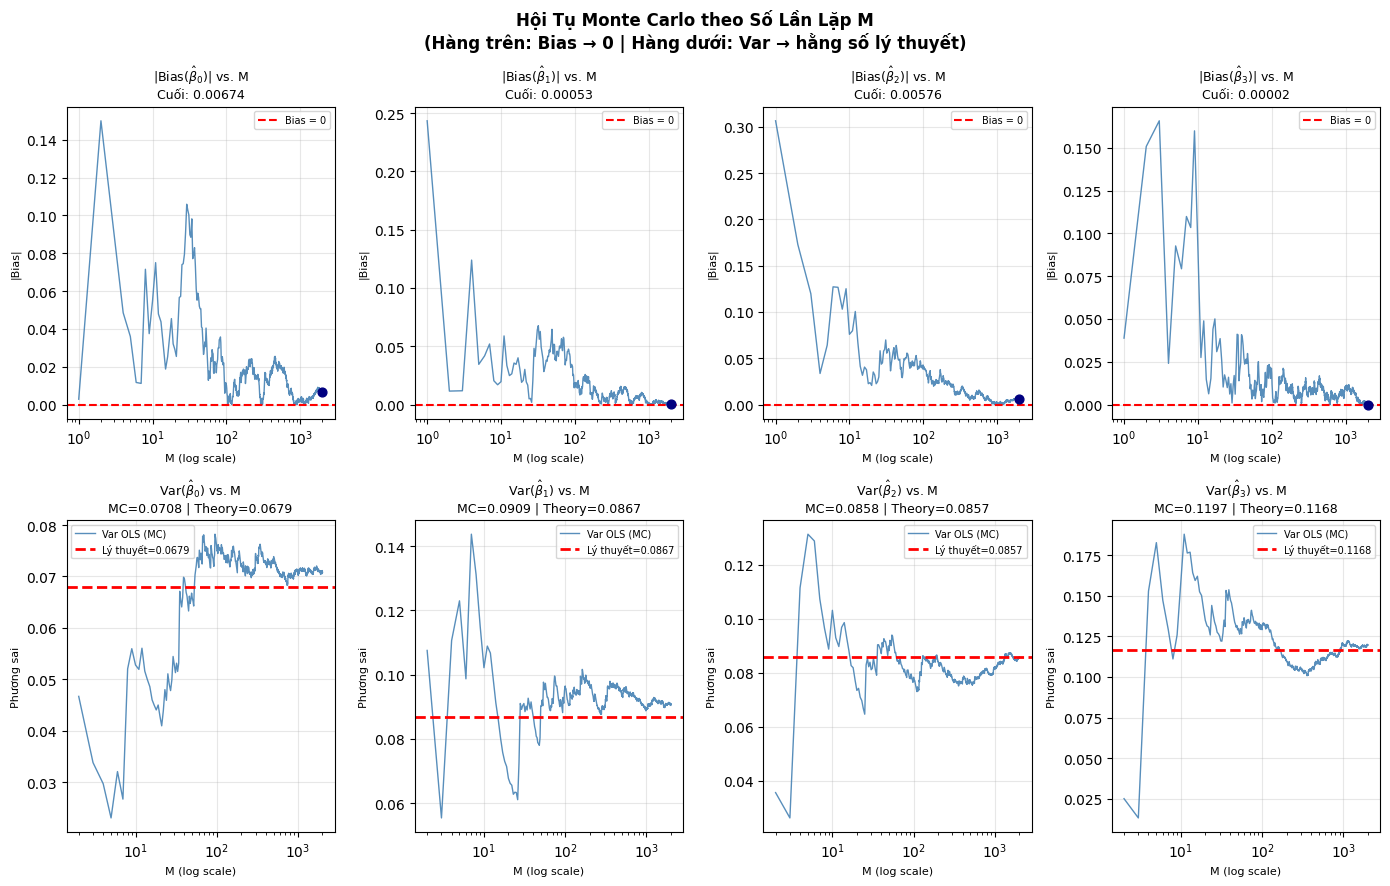

→ Bias hội tụ về 0 khi M tăng (Luật Số Lớn)
→ Var thực nghiệm hội tụ về hằng số lý thuyết


In [9]:
# Tính bias và phương sai tích lũy theo M
# Tại mỗi bước m, dùng toàn bộ m mẫu đã có
cum_mean_ols = np.cumsum(betas_ols, axis=0) / np.arange(1, M + 1).reshape(-1, 1)
cum_bias_ols = np.abs(cum_mean_ols - beta_true)    

# Phương sai tích lũy: tính từ bước m=2 trở đi (ddof=1 cần ít nhất 2 mẫu)
cum_var_ols = np.full((M, p_feat + 1), np.nan)
for m in range(1, M):   # m=1 → dùng 2 mẫu đầu
    cum_var_ols[m] = betas_ols[:m + 1].var(axis=0, ddof=1)

m_range = np.arange(1, M + 1)

fig, axes = plt.subplots(2, p_feat + 1, figsize=(14, 9))
fig.suptitle(
    'Hội Tụ Monte Carlo theo Số Lần Lặp M\n'
    '(Hàng trên: Bias → 0 | Hàng dưới: Var → hằng số lý thuyết)',
    fontsize=12, fontweight='bold'
)

for j in range(p_feat + 1):
    # Hàng trên: hội tụ bias
    ax_b = axes[0, j]
    ax_b.plot(m_range, cum_bias_ols[:, j],
              color='steelblue', linewidth=1.0, alpha=0.9)
    ax_b.axhline(0, color='red', linestyle='--', linewidth=1.5,
                 label='Bias = 0')
    # Đánh dấu giá trị cuối
    ax_b.scatter([M], [cum_bias_ols[-1, j]], color='navy', s=40, zorder=5)
    ax_b.set_title(
        f'|Bias($\\hat{{\\beta}}_{j}$)| vs. M\n'
        f'Cuối: {cum_bias_ols[-1, j]:.5f}',
        fontsize=9
    )
    ax_b.set_xlabel('M (log scale)', fontsize=8)
    ax_b.set_ylabel('|Bias|', fontsize=8)
    ax_b.set_xscale('log')
    ax_b.legend(fontsize=7)
    ax_b.grid(alpha=0.3)

    # Hàng dưới: hội tụ phương sai
    ax_v = axes[1, j]
    ax_v.plot(m_range, cum_var_ols[:, j],
              color='steelblue', linewidth=1.0, alpha=0.9,
              label='Var OLS (MC)')
    ax_v.axhline(var_theory[j], color='red', linestyle='--', linewidth=2.0,
                 label=f'Lý thuyết={var_theory[j]:.4f}')
    ax_v.set_title(
        f'Var($\\hat{{\\beta}}_{j}$) vs. M\n'
        f'MC={cum_var_ols[-1, j]:.4f} | Theory={var_theory[j]:.4f}',
        fontsize=9
    )
    ax_v.set_xlabel('M (log scale)', fontsize=8)
    ax_v.set_ylabel('Phương sai', fontsize=8)
    ax_v.set_xscale('log')
    ax_v.legend(fontsize=7)
    ax_v.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("→ Bias hội tụ về 0 khi M tăng (Luật Số Lớn)")
print("→ Var thực nghiệm hội tụ về hằng số lý thuyết")

---
## Bước 10 — Bảng Tổng Kết và Nhận Xét

In [29]:
# Bảng tổng kết số liệu 
print("═" * 78)
print("  BẢNG TỔNG KẾT — MINH HỌA ĐỊNH LÝ GAUSS–MARKOV")
print(f"  n={n}, p_feat={p_feat}, sigma^2={sigma2}, M={M}")
print("═" * 78)
print(f"{'j':>3} {'β_true':>8} {'E[OLS]':>9} {'BiasOLS':>10} "
      f"{'Var_thy':>10} {'Var_OLS':>10} {'err%':>7} {'Var_Alt':>10} {'Alt/OLS':>8}")
print("─" * 78)
for j in range(p_feat + 1):
    err = abs(var_ols_emp[j] - var_theory[j]) / var_theory[j] * 100
    ratio = var_alt_emp[j] / var_ols_emp[j]
    print(f" {j:>2} {beta_true[j]:>8.3f} {mean_ols[j]:>9.4f} {bias_ols[j]:>10.6f} "
          f"{var_theory[j]:>10.4f} {var_ols_emp[j]:>10.4f} {err:>6.1f}% "
          f"{var_alt_emp[j]:>10.4f} {ratio:>7.2f}×")
print("═" * 78)

print()
print(" NHẬN XÉT:")
print()
print("  1. TÍNH KHÔNG CHỆCH (GM1–GM3):")
print(f"     Bias OLS tối đa = {np.abs(bias_ols).max():.6f} ≈ 0")
print(f"     Bias Alt tối đa = {np.abs(bias_alt).max():.6f} ≈ 0")
print("     → E[β̂_OLS] = β và E[β̃] = β. Cả hai không chệch. ")
print()
print("  2. PHƯƠNG SAI LÝ THUYẾT vs. THỰC NGHIỆM (GM4):")
max_err = np.abs(var_ols_emp - var_theory).max() / var_theory.max() * 100
print(f"     Sai số tương đối tối đa = {max_err:.1f}%")
print("     → Var(β̂_OLS) ≈ σ²(X'X)⁻¹. Công thức lý thuyết được xác nhận.")
print()
print("  3. TÍNH TỐT NHẤT — BLUE (Định lý Gauss–Markov):")
ratios = var_alt_emp / var_ols_emp
print(f"     Var(Alt)/Var(OLS): min={ratios.min():.2f}× | max={ratios.max():.2f}×")
print("     → Var(Alt) > Var(OLS) với mọi j → OLS là BLUE.")
print()
print("  4. PHÂN PHỐI CHUẨN (GM5):")
sw_ps = [stats.shapiro(betas_ols[:1000, j])[1] for j in range(p_feat + 1)]
print(f"     Shapiro-Wilk p-values: {[f'{p:.4f}' for p in sw_ps]}")
print("     → Tất cả p > 0.05: không bác bỏ chuẩn → β̂ ~ N(β, σ²(X'X)⁻¹). ")
print()
print("  5. KẾT LUẬN TỔNG HỢP:")
print("     Kết quả Monte Carlo nhất quán hoàn toàn với Định lý Gauss–Markov:")
print("     OLS vừa không chệch, vừa có phương sai nhỏ nhất trong lớp")
print("     tất cả các ước lượng tuyến tính không chệch. OLS là BLUE. ")

══════════════════════════════════════════════════════════════════════════════
  BẢNG TỔNG KẾT — MINH HỌA ĐỊNH LÝ GAUSS–MARKOV
  n=60, p_feat=3, sigma^2=4.0, M=2000
══════════════════════════════════════════════════════════════════════════════
  j   β_true    E[OLS]    BiasOLS    Var_thy    Var_OLS    err%    Var_Alt  Alt/OLS
──────────────────────────────────────────────────────────────────────────────
  0    2.000    1.9928  -0.007230     0.0678     0.0702    3.5%    21.3986  304.69×
  1   -1.500   -1.4948   0.005208     0.0665     0.0658    1.0%    20.8766  317.34×
  2    3.000    2.9932  -0.006833     0.0646     0.0666    3.0%    36.3723  546.22×
  3    0.500    0.4944  -0.005580     0.0657     0.0626    4.8%    37.8660  604.99×
══════════════════════════════════════════════════════════════════════════════

 NHẬN XÉT:

  1. TÍNH KHÔNG CHỆCH (GM1–GM3):
     Bias OLS tối đa = 0.007230 ≈ 0
     Bias Alt tối đa = 0.213217 ≈ 0
     → E[β̂_OLS] = β và E[β̃] = β. Cả hai không chệch. 

  2